# Recognising handwritten digits with backpropagation

## Loading libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style (same as Task 2)
plt.rcParams.update({'figure.dpi':120, 'font.size':11,
                     'axes.spines.top':False, 'axes.spines.right':False})

## Neural-network functions

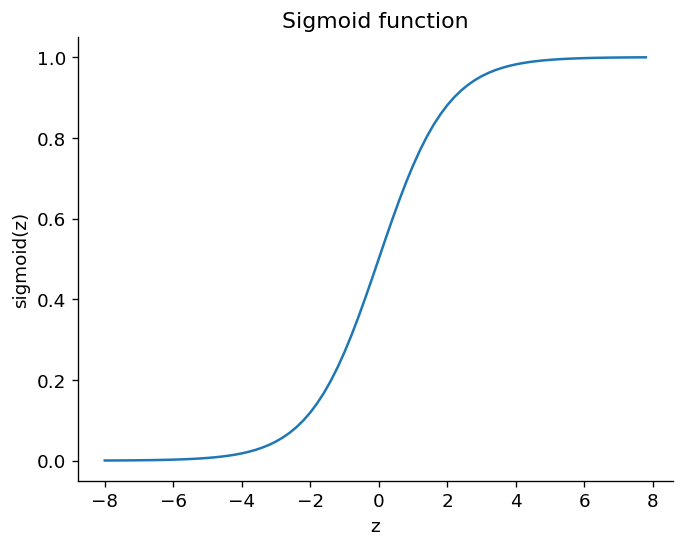

In [2]:
# Sigmoid activation function
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

# Plot the sigmoid
t = np.arange(-8, 8, 0.2)
plt.plot(t, sigmoid(t))
plt.title('Sigmoid function'); plt.xlabel('z'); plt.ylabel('sigmoid(z)')
plt.show()

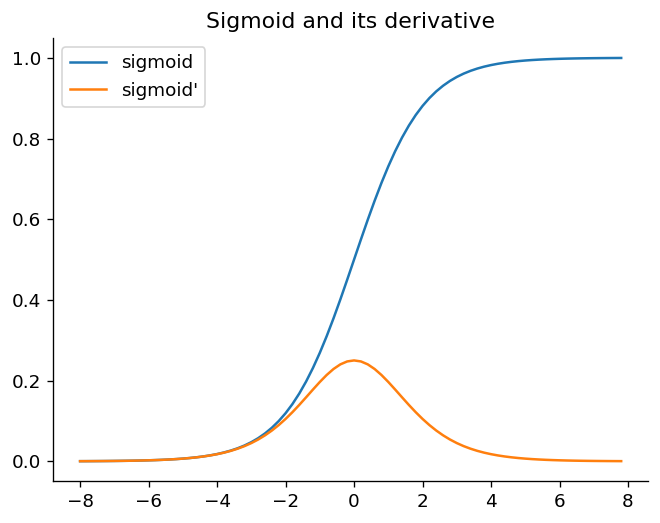

In [3]:
# Derivative of the sigmoid function
def sigmoid_prime(z):
    return sigmoid(z) * (1 - sigmoid(z))

plt.plot(t, sigmoid(t),       label='sigmoid')
plt.plot(t, sigmoid_prime(t), label="sigmoid'")
plt.legend(); plt.title('Sigmoid and its derivative'); plt.show()

In [4]:
# Normalise features to z-scores 
def normalise(X):
    X_mean = np.mean(X, axis=0)
    X_std  = np.std(X, axis=0, ddof=1)
    X_std[X_std == 0] = 1                 
    return (X - X_mean) / X_std, X_mean, X_std

Normalising by subtracting the mean and dividing by the standard deviation. Pixels that never change across images get std=0, which we replace by 1 to avoid division-by-zero errors. The normalisation statistics are computed on the training set only and applied to the test set to prevent data leakage.

In [5]:
# Converting a digit label into a 10-element one-hot column vector
def vectorized_result(j, n_classes=10):
    e = np.zeros((n_classes, 1))
    e[int(j)] = 1.0
    return e

# Example digit 3
print('Digit 3 encoded:', vectorized_result(3).T)

Digit 3 encoded: [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [6]:
# Forward pass
def forward_pass(Weight, bias, x):
    for w, b in zip(Weight, bias):
        x = sigmoid(w @ x + b)
    return x

def forward_pass_all(Weight, bias, inputs):
    return [forward_pass(Weight, bias, x) for x in inputs]

def evaluate(y_preds, y_target):
    return sum([np.argmax(a) == np.argmax(b) for a, b in zip(y_preds, y_target)])

In [7]:
# Evaluate: count correct predictions
def evaluate(y_preds, y_target):
    return sum([np.argmax(a) == np.argmax(b) for a, b in zip(y_preds, y_target)])

We use np.argmax to find the output neuron with the highest activation, which gives the predicted digit. For 10 output neurons this returns a number from 0 to 9, which we compare to the true label.

In [8]:
# Backpropagation
def backpropagation(bias, Weight, num_layers, x, y):
    nabla_b = [np.zeros(len(b)) for b in bias]
    nabla_w = [np.zeros_like(w) for w in Weight]
    act = x
    act_list = [x]
    zs = []
    for w, b in zip(Weight, bias):
        z = w @ act + b
        zs.append(z)
        act = sigmoid(z)
        act_list.append(act)
    delta = sigmoid_prime(zs[-1]) * (act_list[-1] - y)
    nabla_b[-1] = delta
    nabla_w[-1] = np.dot(delta, act_list[-2].transpose())
    for l in range(2, num_layers):
        z     = zs[-l]
        sp    = sigmoid_prime(z)
        delta = np.dot(Weight[-l+1].transpose(), delta) * sp
        nabla_b[-l] = delta
        nabla_w[-l] = np.dot(delta, act_list[-l-1].transpose())
    return nabla_b, nabla_w

## Training Loop

In [9]:
# Initialise weights and biases from a standard normal distribution
def init_network(layers, seed=None):
    if seed is not None:
        np.random.seed(seed)
    bias   = []
    Weight = []
    for i, j in zip(layers, layers[1:]):
        bias.append(np.random.randn(j, 1))
        Weight.append(np.random.randn(j, i))
    return Weight, bias

# Quick test
W_test, b_test = init_network([784, 30, 10], seed=0)
print('Layer 1 weight shape:', W_test[0].shape, ' bias shape:', b_test[0].shape)
print('Layer 2 weight shape:', W_test[1].shape, ' bias shape:', b_test[1].shape)

Layer 1 weight shape: (30, 784)  bias shape: (30, 1)
Layer 2 weight shape: (10, 30)  bias shape: (10, 1)


The input layer has 784 neurons (one per pixel), and with 30 hidden neurons the first weight matrix is (30 × 784). The output layer has 10 neurons (one per digit class), giving a (10 × 30) weight matrix.

In [10]:
def sgd_one_epoch(Weight, bias, training_inputs, training_results, eta):
    num_layers = len(Weight) + 1
    ix = np.arange(len(training_inputs))
    np.random.shuffle(ix)
    for i in ix:
        nb, nw = backpropagation(bias, Weight, num_layers, training_inputs[i], training_results[i])
        Weight = [w - eta*nw_ for w, nw_ in zip(Weight, nw)]
        bias   = [b - eta*nb_ for b, nb_ in zip(bias,   nb)]
    return Weight, bias


# Minibatch
def mini_batch_one_epoch(Weight, bias, training_inputs, training_results, eta, batch_size):
    num_layers = len(Weight) + 1
    n  = len(training_inputs)
    ix = np.arange(n)
    np.random.shuffle(ix)
    for start in range(0, n, batch_size):
        batch = ix[start : start + batch_size]
        m = len(batch)
        nb_sum = [np.zeros_like(b) for b in bias]
        nw_sum = [np.zeros_like(w) for w in Weight]
        for i in batch:
            nb, nw = backpropagation(bias, Weight, num_layers,
                                     training_inputs[i], training_results[i])
            nb_sum = [a + b for a, b in zip(nb_sum, nb)]
            nw_sum = [a + b for a, b in zip(nw_sum, nw)]
        Weight = [w - (eta/m)*nw_ for w, nw_ in zip(Weight, nw_sum)]
        bias   = [b - (eta/m)*nb_ for b, nb_ in zip(bias,   nb_sum)]
    return Weight, bias


def train_network(layers, training_inputs, training_results,
                  test_inputs=None, test_results=None,
                  eta=0.1, batch_size=32, n_epochs=10, seed=SEED):
    Weight, bias = init_network(layers, seed=seed)
    train_acc_history = []
    test_acc_history  = []
    for epoch in range(n_epochs):
        if batch_size == 1:
            Weight, bias = sgd_one_epoch(Weight, bias, training_inputs,
                                         training_results, eta)
        else:
            Weight, bias = mini_batch_one_epoch(Weight, bias, training_inputs,
                                                training_results, eta, batch_size)
        tr_preds = forward_pass_all(Weight, bias, training_inputs)
        train_acc_history.append(evaluate(tr_preds, training_results) / len(training_results))
        if test_inputs is not None:
            te_preds = forward_pass_all(Weight, bias, test_inputs)
            test_acc_history.append(evaluate(te_preds, test_results) / len(test_results))
    return Weight, bias, train_acc_history, test_acc_history

## Data loading & exploratory analysis


In [11]:
# Load MNIST

from sklearn.datasets import fetch_openml

X_train_raw = y_train_raw = X_test_raw = y_test_raw = None

try:
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

    X_all = mnist.data.astype(np.uint8)   # (70000, 784)
    y_all = mnist.target.astype(int)

    X_train_raw = X_all[:60000].reshape(-1, 28, 28)
    y_train_raw = y_all[:60000]

    X_test_raw = X_all[60000:].reshape(-1, 28, 28)
    y_test_raw = y_all[60000:]


except Exception as e:
    print('Failed to load MNIST ')

if X_train_raw is not None:
    print('Training images shape:', X_train_raw.shape)   # (60000, 28, 28)
    print('Test images shape:    ', X_test_raw.shape)    # (10000, 28, 28)
    print('Pixel value range:    ', X_train_raw.min(), '–', X_train_raw.max())
    print('Digit classes:        ', sorted(set(y_train_raw)))


Training images shape: (60000, 28, 28)
Test images shape:     (10000, 28, 28)
Pixel value range:     0 – 255
Digit classes:         [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


MNIST dataset has 60,000 training images and 10,000 test images. Each image is 28×28 pixels, and pixel values are integers from 0 (black) to 255 (white). There are 10 classes, one for each digit from 0 to 9.

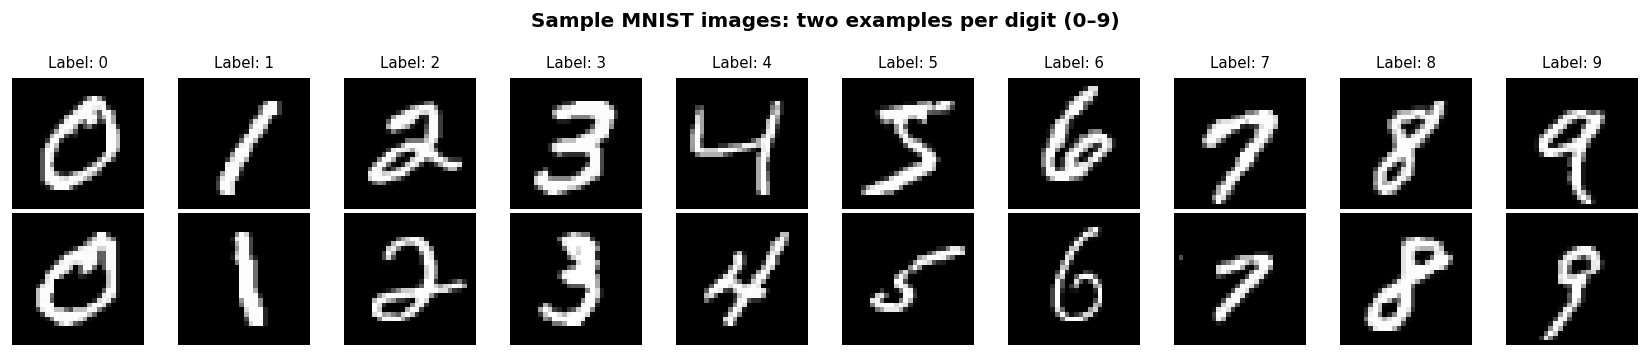

In [12]:
# Visualise a sample of digits 
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]  
    axes[0, digit].imshow(X_train_raw[idx], cmap='gray')
    axes[0, digit].set_title(f'Label: {digit}', fontsize=9)
    axes[0, digit].axis('off')
    idx2 = np.where(y_train_raw == digit)[0][1]  
    axes[1, digit].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, digit].axis('off')
fig.suptitle('Sample MNIST images: two examples per digit (0–9)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Each image is a 28×28 black and white (gray feature). The pixel intensities vary from 0 (black background) to 255 (white pen strokes). Even for the same digit, two examples already look quite different in stroke width, angle and size — which is exactly the challenge the network needs to solve.

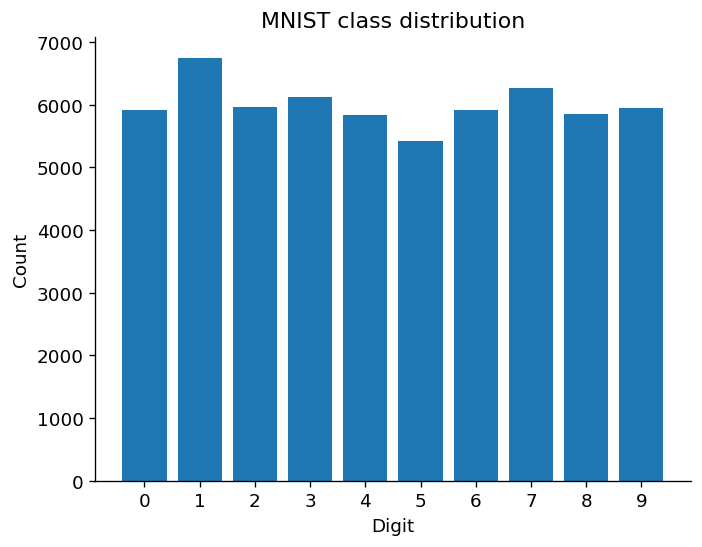

Digit counts: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [13]:
digit_counts = np.bincount(y_train_raw)

plt.bar(range(10), digit_counts)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST class distribution")
plt.show()

print("Digit counts:", digit_counts)

MNIST is a well-balanced dataset with roughly 5,000–6,000 examples per digit. The majority-class baseline (always predicting the most common digit) gives only about 11.4% accuracy, which means any model that learns something meaningful should perform well above this number.

## Data preprocessing

In [14]:
# Flatten 28×28 → 784 and scale to [0, 1]
X_train_flat = X_train_raw.reshape(-1, 784).astype(np.float32) / 255.0
X_test_flat  = X_test_raw.reshape(-1, 784).astype(np.float32)  / 255.0

print('Flattened training shape:', X_train_flat.shape)  # (60000, 784)
print('Pixel range after scaling:', X_train_flat.min(), '–', X_train_flat.max())

Flattened training shape: (60000, 784)
Pixel range after scaling: 0.0 – 1.0


In [15]:
# Step 2: z-score normalisation fitted on training set only
X_train_norm, train_mean, train_std = normalise(X_train_flat)
X_test_norm = (X_test_flat - train_mean) / train_std

print('After normalisation the training mean=', X_train_norm.mean().round(4),
      ' std ≈', X_train_norm.std().round(4))

After normalisation the training mean= -0.0  std ≈ 0.9563


Dividing by 255 puts every pixel in [0, 1], which helps the sigmoid function work in its responsive region. The subsequent z-score normalisation centres each pixel feature around 0 with unit variance, preventing bright pixels from dominating weight updates over dark ones. 

## Task 3a: Why are 784 input neurons appropriate?


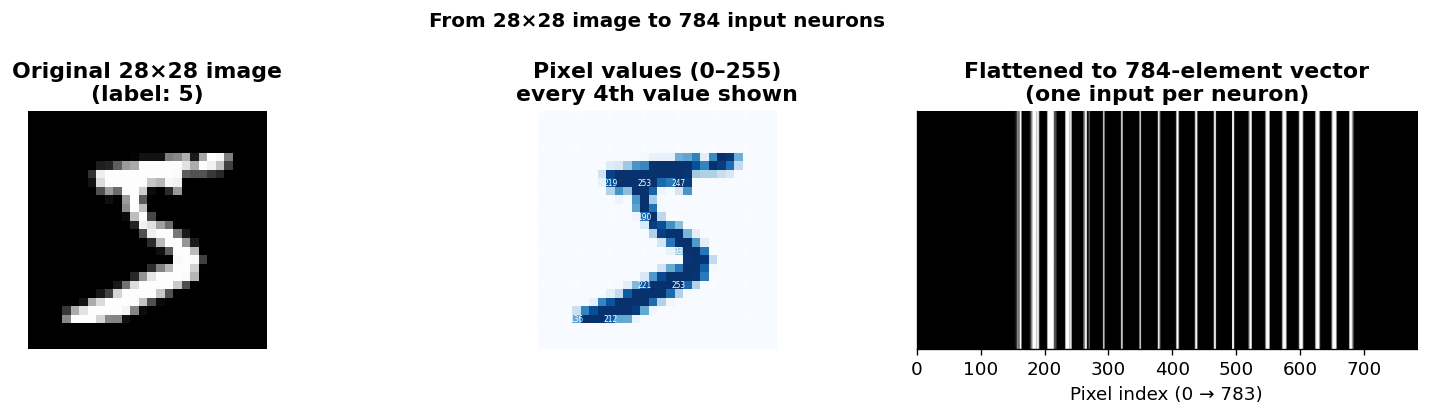

Image dimensions: (28, 28)
28 × 28 = 784 pixels  →  784 input neurons


In [16]:
sample_idx = 0
sample_image = X_train_raw[sample_idx]     
sample_flat  = X_train_flat[sample_idx]    

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# Original image
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title(f'Original 28×28 image\n(label: {y_train_raw[sample_idx]})', fontweight='bold')
axes[0].axis('off')

# Pixel values
axes[1].imshow(sample_image, cmap='Blues')
for row in range(0, 28, 4):          
    for col in range(0, 28, 4):
        axes[1].text(col, row, str(sample_image[row, col]),
                     ha='center', va='center', fontsize=4.5, color='white')
axes[1].set_title('Pixel values (0–255)\nevery 4th value shown', fontweight='bold')
axes[1].axis('off')

# Flattened vector 
axes[2].imshow(sample_flat.reshape(1, 784), cmap='gray', aspect='auto')
axes[2].set_title(f'Flattened to 784-element vector\n(one input per neuron)', fontweight='bold')
axes[2].set_yticks([])
axes[2].set_xlabel('Pixel index (0 → 783)')

plt.suptitle('From 28×28 image to 784 input neurons', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Image dimensions: {sample_image.shape}')
print(f'28 × 28 = {28*28} pixels  →  784 input neurons')

### Explanation

- Each MNIST image is a 28×28 grid of pixels, giving 28 × 28 = 784 pixels in total
- Before feeding the image into the network we flatten this 2D grid into a single 1D vector of 784 numbers
- Each number becomes the input to one input neuron
- A bright pixel at a specific location is a signal that a certain digit is likely, so each pixel plays the role of a feature
- 784 input neurons is not a random choice but a consequence of the image resolution: 28 × 28 = 784
- The network architecture is written as [784, N, 10] where 784 is fixed by the data, N is the number of hidden neurons we can tune, and 10 is fixed by the number of digit classes

## Task 3b: Why are 10 output neurons appropriate?


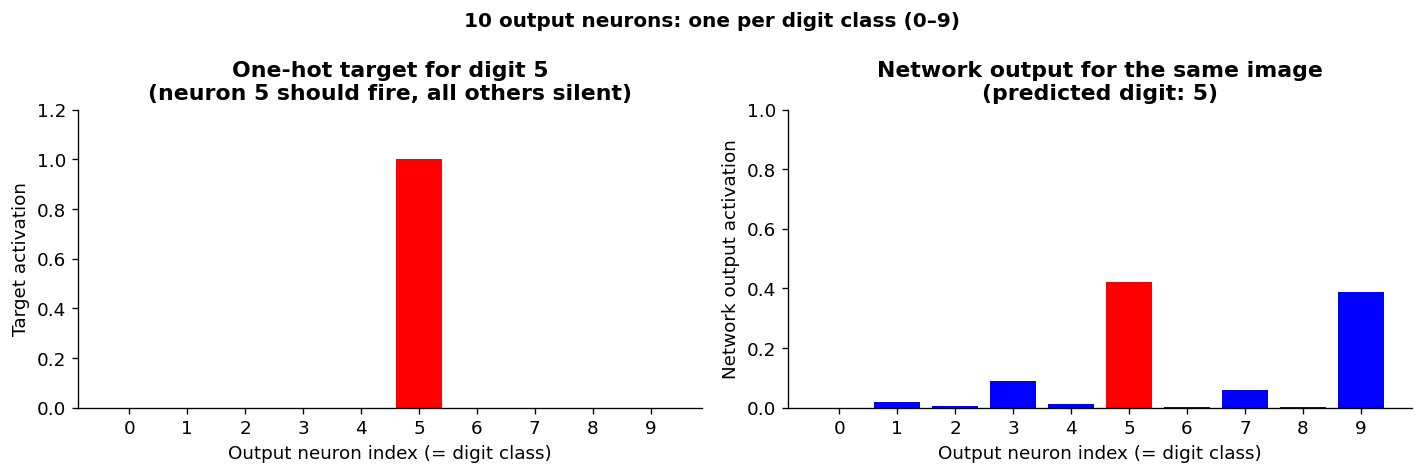

One-hot vector for digit 5 :
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One-hot encoding for digit 5
target_digit = 5
target_vector = vectorized_result(target_digit)
axes[0].bar(range(10), target_vector.flatten(),
            color=['red' if i == target_digit else 'blue' for i in range(10)])
axes[0].set_xticks(range(10))
axes[0].set_xlabel('Output neuron index (= digit class)')
axes[0].set_ylabel('Target activation')
axes[0].set_title(f'One-hot target for digit {target_digit}\n(neuron {target_digit} should fire, all others silent)',
                  fontweight='bold')
axes[0].set_ylim(0, 1.2)

# Output trained network (fake)
np.random.seed(7)
fake_output = np.random.dirichlet(np.ones(10) * 0.3)
fake_output[target_digit] = 0.72   
fake_output = fake_output / fake_output.sum()
axes[1].bar(range(10), fake_output,
            color=['red' if i == target_digit else 'blue' for i in range(10)])
axes[1].set_xticks(range(10))
axes[1].set_xlabel('Output neuron index (= digit class)')
axes[1].set_ylabel('Network output activation')
axes[1].set_title(f'Network output for the same image\n(predicted digit: {np.argmax(fake_output)})',
                  fontweight='bold')
axes[1].set_ylim(0, 1.0)

plt.suptitle('10 output neurons: one per digit class (0–9)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('One-hot vector for digit', target_digit, ':')
print(vectorized_result(target_digit).T)

### Explanation

- MNIST has 10 digit classes (0 through 9) so we use one output neuron per class
- The predicted digit is whichever neuron has the highest activation: predicted_digit = argmax(output)
- The target for each image is a 10-element one-hot vector: all zeros except a 1 at the position of the true digit

    - Alternative: use a single output neuron with target values 0.0 for digit 0, 0.1 for digit 1... 0.9 for digit 9. This is not a good approach because it assumes digits are equally spaced and numerically ordered, which they are not, they are arbitrary labels

## Task 3c: Parameter search on a smaller subset


In [18]:
# Subset size 
SUBSET_TRAIN = 5000
SUBSET_TEST  = 1000
N_EPOCHS_SEARCH = 15

X_sub_train = X_train_norm[:SUBSET_TRAIN]
y_sub_train = y_train_raw[:SUBSET_TRAIN]
X_sub_test  = X_test_norm[:SUBSET_TEST]
y_sub_test  = y_test_raw[:SUBSET_TEST]

# Convert to lists of column vectors and one-hot targets
sub_train_inputs  = [X_sub_train[i].reshape(784, 1) for i in range(SUBSET_TRAIN)]
sub_train_targets = [vectorized_result(y_sub_train[i]) for i in range(SUBSET_TRAIN)]
sub_test_inputs   = [X_sub_test[i].reshape(784, 1)  for i in range(SUBSET_TEST)]
sub_test_targets  = [vectorized_result(y_sub_test[i]) for i in range(SUBSET_TEST)]

print(f'Subset: {SUBSET_TRAIN} training examples, {SUBSET_TEST} test examples')
print(f'Majority-class baseline on subset: {np.bincount(y_sub_test.astype(int)).max()/SUBSET_TEST*100:.1f}%')

Subset: 5000 training examples, 1000 test examples
Majority-class baseline on subset: 12.6%


In [19]:
# Test 1: vary learning rate, fix hidden layer size at 30

learning_rates = [ 0.01, 0.1, 0.5, 1.0]
fixed_layers   = [784, 30, 10]

lr_results = {}
print(f'Varying learning rate on [784, 30, 10] for {N_EPOCHS_SEARCH} epochs (batch=32):')
print(f'{"eta":>6}  {"Final train acc":>16}  {"Final test acc":>14}')
print('-' * 42)

for eta in learning_rates:
    W, b, tr_h, val_h = train_network(
        fixed_layers, sub_train_inputs, sub_train_targets,
        sub_test_inputs, sub_test_targets,
        eta=eta, batch_size=32, n_epochs=N_EPOCHS_SEARCH, seed=SEED)
    lr_results[eta] = {'train': tr_h, 'val': val_h, 'W': W, 'b': b}
    print(f'{eta:>6.2f}  {tr_h[-1]:>16.4f}  {val_h[-1]:>14.4f}')

Varying learning rate on [784, 30, 10] for 15 epochs (batch=32):
   eta   Final train acc  Final test acc
------------------------------------------
  0.01            0.1052          0.0940
  0.10            0.2514          0.2430
  0.50            0.6450          0.5940
  1.00            0.7342          0.6830


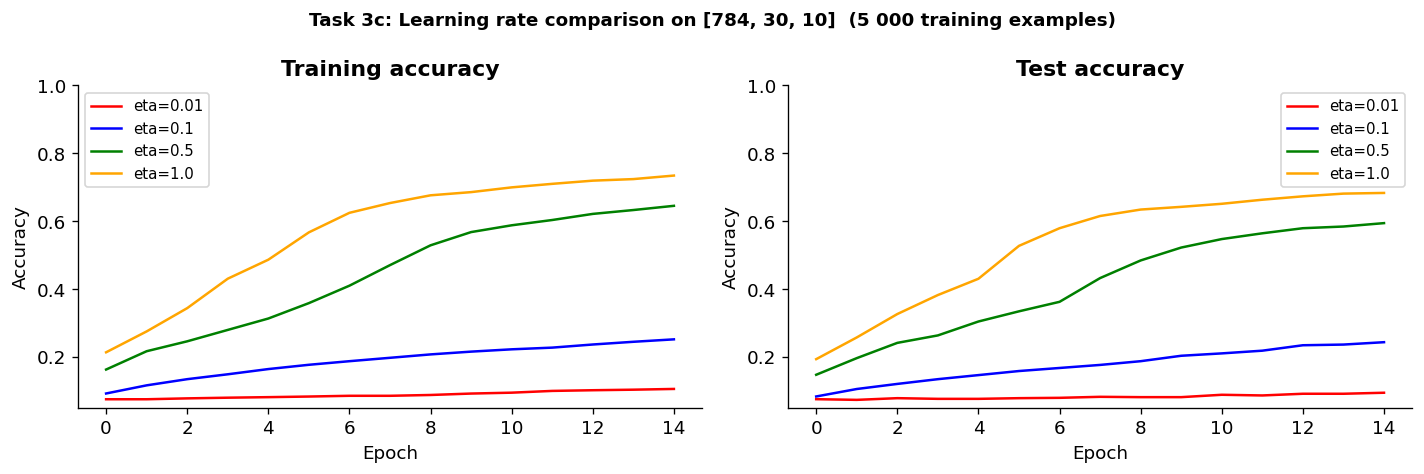

In [20]:
colors = ['red', 'blue', 'green', 'orange']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (eta, res), col in zip(lr_results.items(), colors):
    axes[0].plot(res['train'], label=f'eta={eta}', color=col)
    axes[1].plot(res['val'],   label=f'eta={eta}', color=col)

for ax, title in zip(axes, ['Training accuracy', 'Test accuracy']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.set_ylim(0.05, 1.0)

plt.suptitle('Task 3c: Learning rate comparison on [784, 30, 10]  (5 000 training examples)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

- Small learning rates don't manage to achieve good accuracies
- From the range, eta =1 is our best option and it still has an adequate stability

Since we are at the higher end of our range, we will perform another test, to explore bigger etas. 

In [21]:
# Test 1.2: vary HIGHER learning rate, fix hidden layer size at 30

learning_rates = [ 1.0, 3.0, 6.0, 10.0]
fixed_layers = [784, 30, 10]

lr_results = {}
print(f'Varying learning rate on [784, 30, 10] for {N_EPOCHS_SEARCH} epochs (batch=32):')
print(f'{"eta":>6}  {"Final train acc":>16}  {"Final test acc":>14}')
print('-' * 42)

for eta in learning_rates:
    W, b, tr_h, val_h = train_network(
        fixed_layers, sub_train_inputs, sub_train_targets,
        sub_test_inputs, sub_test_targets,
        eta=eta, batch_size=32, n_epochs=N_EPOCHS_SEARCH, seed=SEED)
    lr_results[eta] = {'train': tr_h, 'val': val_h, 'W': W, 'b': b}
    print(f'{eta:>6.2f}  {tr_h[-1]:>16.4f}  {val_h[-1]:>14.4f}')

Varying learning rate on [784, 30, 10] for 15 epochs (batch=32):
   eta   Final train acc  Final test acc
------------------------------------------
  1.00            0.7342          0.6830
  3.00            0.8930          0.8040
  6.00            0.9308          0.8290
 10.00            0.9440          0.8460


 Despite this, as ETA increases, so does the gap between train and test. At eta=1 the train and test are very close (73.4% and 68.3%), but the higher we go, the gap goes up to a 10% difference. This indicates that the model is starting to memorize the training data instead of learning general patterns, which is what we are looking for.

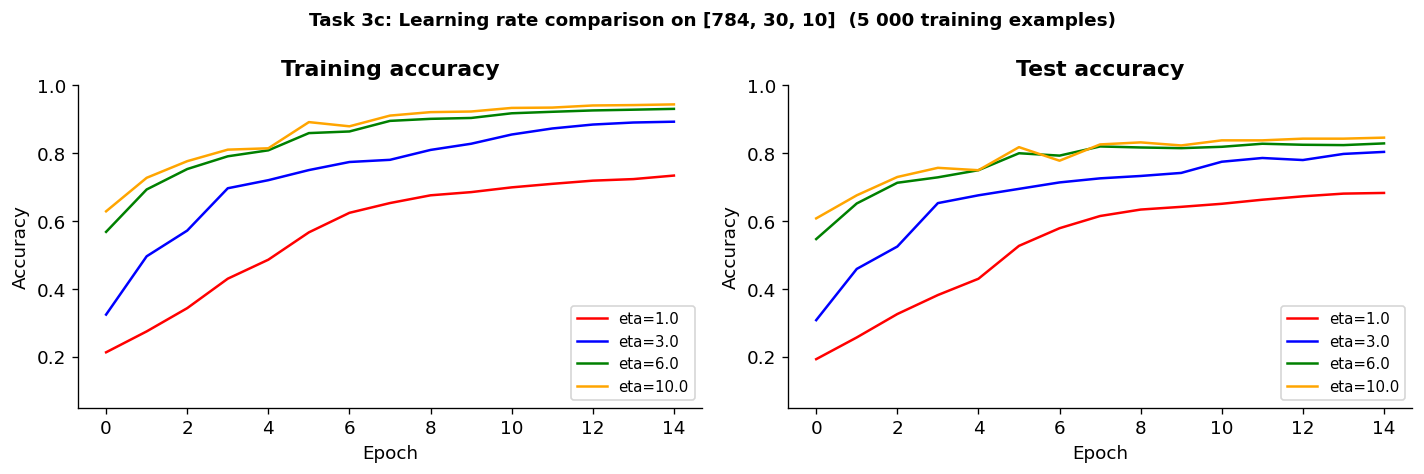

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (eta, res), col in zip(lr_results.items(), colors):
    axes[0].plot(res['train'], label=f'eta={eta}', color=col)
    axes[1].plot(res['val'],   label=f'eta={eta}', color=col)

for ax, title in zip(axes, ['Training accuracy', 'Test accuracy']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.set_ylim(0.05, 1.0)

plt.suptitle('Task 3c: Learning rate comparison on [784, 30, 10]  (5 000 training examples)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

After running higher rates than in test 1, we get results that show much higher accuracy values. We choose eta = 3 as the best balance. It gives achieves a improvement over the lower rates (test accuracy goes from 68.3% at eta = 1 to 80.4% at eta = 3), while keeping the train-test gap below 10% (89.3% train to 80.4% test). Higher rates like eta = 6 or eta = 10 give a slightly better test accuracy, but with a bigger gap and the risk of becoming unstable on the full dataset. Another thing to point out is that the value of eta = 3 is also the one used in Michael Nielsen's  MNIST tutorial, which uses the same [784, 30, 10] network architecture as us.

In [23]:
# Test 2: vary hidden layer size, fix learning rate at BEST_ETA= 3

hidden_sizes = [10, 30, 60, 100]
BEST_ETA= 3.0

hs_results = {}
print(f'Varying hidden layer size with eta={BEST_ETA} for {N_EPOCHS_SEARCH} epochs (batch=32):')
print(f'{"Architecture":>16}  {"Final train acc":>16}  {"Final test acc":>14}')
print('-' * 52)

for n_hidden in hidden_sizes:
    layers = [784, n_hidden, 10]
    W, b, tr_h, val_h = train_network(
        layers, sub_train_inputs, sub_train_targets,
        sub_test_inputs, sub_test_targets,
        eta=BEST_ETA, batch_size=32, n_epochs=N_EPOCHS_SEARCH, seed=SEED)
    key = f'[784,{n_hidden},10]'
    hs_results[key] = {'train': tr_h, 'val': val_h, 'W': W, 'b': b, 'n': n_hidden}
    print(f'{key:>16}  {tr_h[-1]:>16.4f}  {val_h[-1]:>14.4f}')

Varying hidden layer size with eta=3.0 for 15 epochs (batch=32):
    Architecture   Final train acc  Final test acc
----------------------------------------------------
     [784,10,10]            0.8828          0.7800
     [784,30,10]            0.8930          0.8040
     [784,60,10]            0.7962          0.7210
    [784,100,10]            0.8060          0.7190


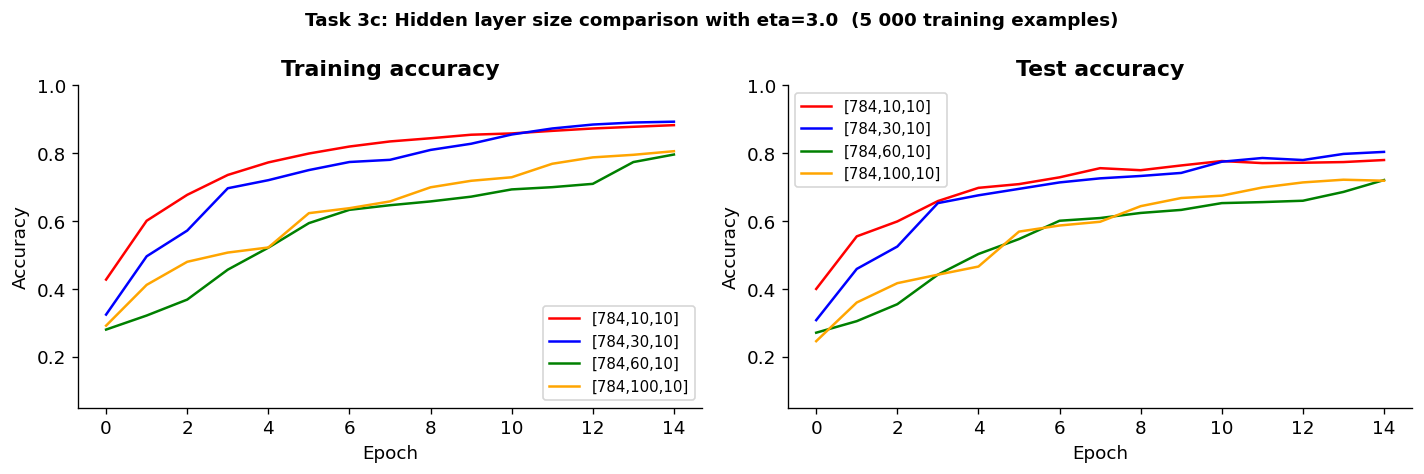

In [24]:
# Hidden layer size comparison
colors = ['red', 'blue', 'green', 'orange']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for (key, res), col in zip(hs_results.items(), colors):
    axes[0].plot(res['train'], label=key, color=col)
    axes[1].plot(res['val'],   label=key, color=col)

for ax, title in zip(axes, ['Training accuracy', 'Test accuracy']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.set_ylim(0.05, 1.0)

plt.suptitle(f'Task 3c: Hidden layer size comparison with eta={BEST_ETA}  (5 000 training examples)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

- 10 hidden neurons gets a reasonable test accuracy (78.0%) but is slightly limited in capacity to capture the full variety of handwriting styles.
- 30 hidden neurons reaches the best test accuracy (80.4%), striking a good balance between capacity and stable learning.
- 60 and 100 hidden neurons perform worse (72.1% and 71.9%), the opposite of what we expected. With larger weight matrices the sums going into the sigmoid get pushed to extreme values where the gradient is almost zero, so the network can barely learn.

We select **30 hidden neurons** as the best architecture for our [784, 30, 10] network.

In [25]:
# Summary table of all test
print('Summary of 3c tests (5,000 training examples, 15 epochs)')
print('test 1.2: learning rate (hidden = 30)')
print(f'{"eta":>6}  {"Train acc":>10}  {"Test acc":>10}')
print('-' * 32)
for eta, res in lr_results.items():
    print(f'{eta:>6.2f}  {res["train"][-1]:>10.4f}  {res["val"][-1]:>10.4f}')

print(f'test 2: hidden layer size (eta = {BEST_ETA})')
print(f'{"Architecture":>16}  {"Train acc":>10}  {"Test acc":>10}')
print('-' * 42)
for key, res in hs_results.items():
    print(f'{key:>16}  {res["train"][-1]:>10.4f}  {res["val"][-1]:>10.4f}')

print(f'Best parameters: eta = {BEST_ETA}, hidden layer size = 30')
print('Best architecture: [784, 30, 10]')

Summary of 3c tests (5,000 training examples, 15 epochs)
test 1.2: learning rate (hidden = 30)
   eta   Train acc    Test acc
--------------------------------
  1.00      0.7342      0.6830
  3.00      0.8930      0.8040
  6.00      0.9308      0.8290
 10.00      0.9440      0.8460
test 2: hidden layer size (eta = 3.0)
    Architecture   Train acc    Test acc
------------------------------------------
     [784,10,10]      0.8828      0.7800
     [784,30,10]      0.8930      0.8040
     [784,60,10]      0.7962      0.7210
    [784,100,10]      0.8060      0.7190
Best parameters: eta = 3.0, hidden layer size = 30
Best architecture: [784, 30, 10]


In [26]:
# Run with best parameters: [784, 30, 10], eta=3.0, 20 epochs
N_EPOCHS_FINAL = 20
best_layers = [784, 30, 10]

W_best, b_best, tr_best, val_best = train_network(
    best_layers, sub_train_inputs, sub_train_targets,
    sub_test_inputs, sub_test_targets,
    eta=BEST_ETA, batch_size=32, n_epochs=N_EPOCHS_FINAL, seed=SEED)

print(f'Best model [784,30,10] final training accuracy:  {tr_best[-1]:.4f}')
print(f'Best model [784,30,10] final test accuracy:      {val_best[-1]:.4f}')

Best model [784,30,10] final training accuracy:  0.9114
Best model [784,30,10] final test accuracy:      0.8090


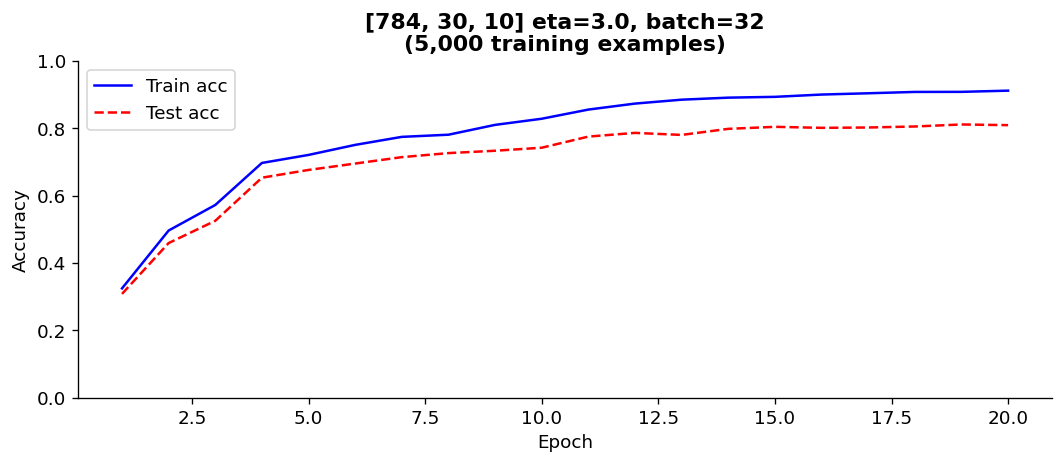

In [27]:
# Training curve for the best model on the subset
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, N_EPOCHS_FINAL + 1)
ax.plot(epochs, tr_best,  label='Train acc', color='blue')
ax.plot(epochs, val_best, label='Test acc',  color='red', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title(f'[784, 30, 10] eta={BEST_ETA}, batch=32\n(5,000 training examples)',
             fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

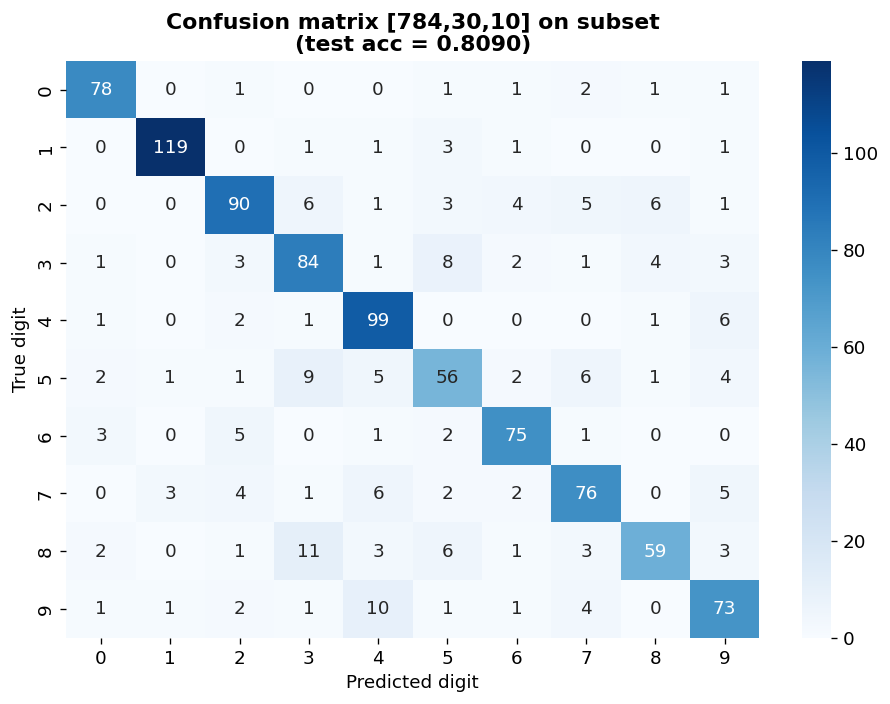

Per-digit accuracy:
  Digit 0: 78/85 = 91.8%
  Digit 1: 119/126 = 94.4%
  Digit 2: 90/116 = 77.6%
  Digit 3: 84/107 = 78.5%
  Digit 4: 99/110 = 90.0%
  Digit 5: 56/87 = 64.4%
  Digit 6: 75/87 = 86.2%
  Digit 7: 76/99 = 76.8%
  Digit 8: 59/89 = 66.3%
  Digit 9: 73/94 = 77.7%


In [28]:
# Confusion matrix
te_preds_best = [int(np.argmax(forward_pass(W_best, b_best, x))) for x in sub_test_inputs]
cm = confusion_matrix(y_sub_test.astype(int), te_preds_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted digit'); ax.set_ylabel('True digit')
ax.set_title(f'Confusion matrix [784,30,10] on subset\n'
             f'(test acc = {val_best[-1]:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

print('Per-digit accuracy:')
for digit in range(10):
    correct = cm[digit, digit]
    total   = cm[digit, :].sum()
    print(f'  Digit {digit}: {correct}/{total} = {correct/total*100:.1f}%')

## Task 3d: Performance on the entire dataset


In [29]:
# Convert the full dataset to column vectors and one-hot targets
N_TRAIN = X_train_norm.shape[0]
N_TEST  = X_test_norm.shape[0]

full_train_inputs  = [X_train_norm[i].reshape(784, 1) for i in range(N_TRAIN)]
full_train_targets = [vectorized_result(y_train_raw[i]) for i in range(N_TRAIN)]
full_test_inputs   = [X_test_norm[i].reshape(784, 1)  for i in range(N_TEST)]
full_test_targets  = [vectorized_result(y_test_raw[i]) for i in range(N_TEST)]

print(f'Full dataset: {N_TRAIN} training examples, {N_TEST} test examples')
print(f'Majority-class baseline on full test: {np.bincount(y_test_raw.astype(int)).max()/N_TEST*100:.1f}%')

Full dataset: 60000 training examples, 10000 test examples
Majority-class baseline on full test: 11.3%


In [30]:
# Train on the full 60,000 examples with the best parameters from 3c
N_EPOCHS_FULL = 20
full_layers   = [784, 30, 10]

W_full, b_full, tr_full, val_full = train_network(
    full_layers, full_train_inputs, full_train_targets,
    full_test_inputs, full_test_targets,
    eta=BEST_ETA, batch_size=32, n_epochs=N_EPOCHS_FULL, seed=SEED)

print(f'Full-dataset model [784,30,10] final training accuracy:  {tr_full[-1]:.4f}')
print(f'Full-dataset model [784,30,10] final test accuracy:      {val_full[-1]:.4f}')

Full-dataset model [784,30,10] final training accuracy:  0.9460
Full-dataset model [784,30,10] final test accuracy:      0.9181


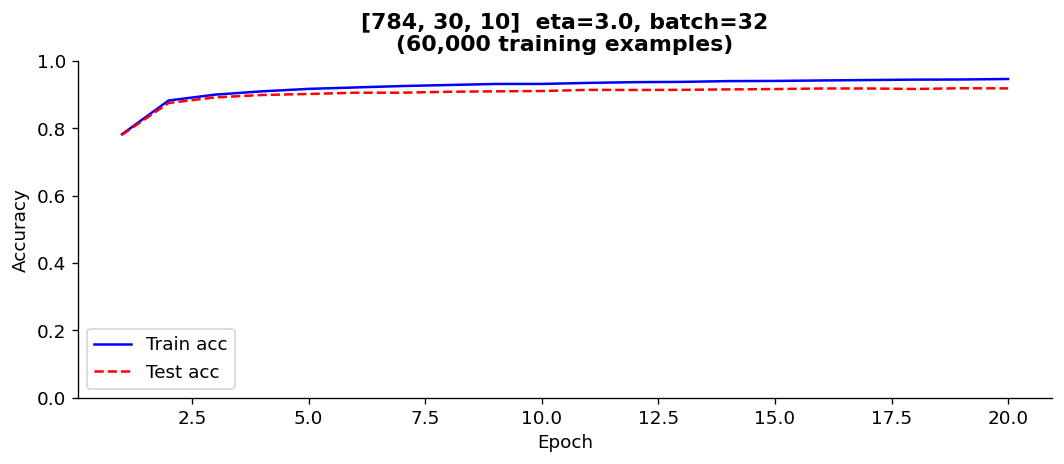

In [31]:
# Training curve for the full dataset model
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, N_EPOCHS_FULL + 1)
ax.plot(epochs, tr_full,  label='Train acc', color='blue')
ax.plot(epochs, val_full, label='Test acc',  color='red', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title(f'[784, 30, 10]  eta={BEST_ETA}, batch=32\n(60,000 training examples)',
             fontweight='bold')
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

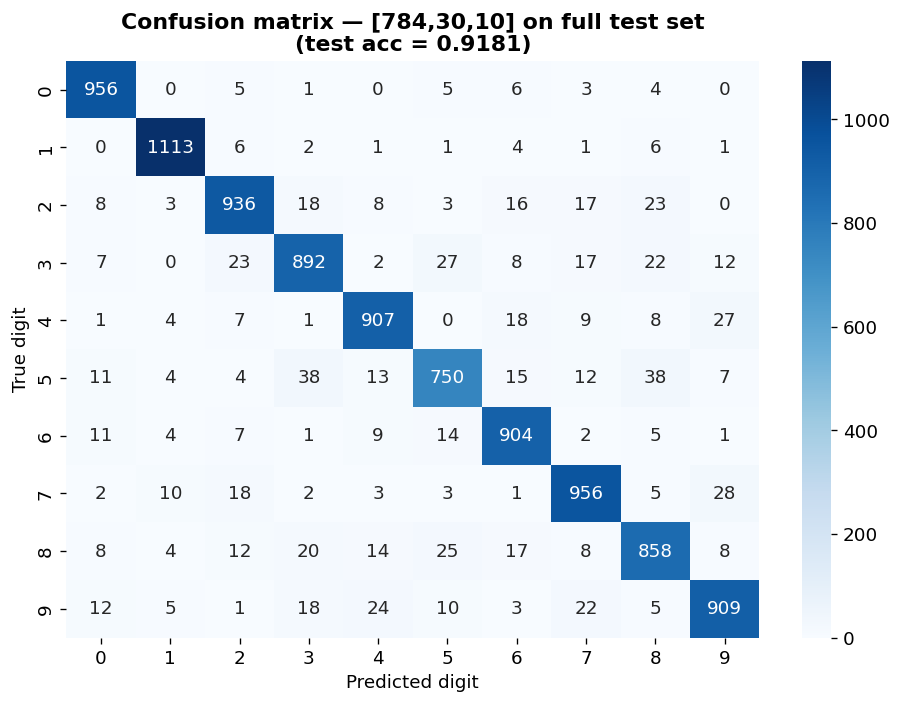

Overall test accuracy on full dataset: 0.9181
Per-digit accuracy:
  Digit 0: 956/980 = 97.6%
  Digit 1: 1113/1135 = 98.1%
  Digit 2: 936/1032 = 90.7%
  Digit 3: 892/1010 = 88.3%
  Digit 4: 907/982 = 92.4%
  Digit 5: 750/892 = 84.1%
  Digit 6: 904/958 = 94.4%
  Digit 7: 956/1028 = 93.0%
  Digit 8: 858/974 = 88.1%
  Digit 9: 909/1009 = 90.1%


In [32]:
# Confusion matrix on the full test set
te_preds_full = [int(np.argmax(forward_pass(W_full, b_full, x))) for x in full_test_inputs]
cm_full = confusion_matrix(y_test_raw.astype(int), te_preds_full)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_full, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted digit'); ax.set_ylabel('True digit')
ax.set_title(f'Confusion matrix — [784,30,10] on full test set\n'
             f'(test acc = {val_full[-1]:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

overall_acc = np.trace(cm_full) / np.sum(cm_full)
print(f'Overall test accuracy on full dataset: {overall_acc:.4f}')

print('Per-digit accuracy:')
for digit in range(10):
    correct = cm_full[digit, digit]
    total   = cm_full[digit, :].sum()
    print(f'  Digit {digit}: {correct}/{total} = {correct/total*100:.1f}%')

In [33]:
# Summary of Task 3 results
print('Task 3: summary of results')
print()

print('3a Input layer: 784 neurons (one per pixel of the 28×28 image)')
print('    Architecture: [784, N, 10] — 784 fixed by image resolution')
print()
print('3b Output layer: 10 neurons (one per digit class, 0–9)')
print('    Alternative: 1 output with continuous targets (0.0–0.9) — rejected,')
print('    since digit labels are categorical, not ordered')
print()
print('3c Best parameters found on 5,000-example subset:')
print(f'    Best learning rate: 3.0')
print(f'    Best hidden size:   30')
print(f'    Best architecture:  [784, 30, 10]')
print(f'    Subset train acc:   {tr_best[-1]:.4f}')
print(f'    Subset test acc:    {val_best[-1]:.4f}')
print(f'    Train-test gap:     {(tr_best[-1]-val_best[-1])*100:.1f}pp')
print()
print('3d Full dataset training (60,000 examples, 20 epochs):')
print(f'    Train accuracy: {tr_full[-1]:.4f}')
print(f'    Test accuracy:  {val_full[-1]:.4f}')
print(f'    Train-test gap: {(tr_full[-1]-val_full[-1])*100:.1f}pp')

Task 3: summary of results

3a Input layer: 784 neurons (one per pixel of the 28×28 image)
    Architecture: [784, N, 10] — 784 fixed by image resolution

3b Output layer: 10 neurons (one per digit class, 0–9)
    Alternative: 1 output with continuous targets (0.0–0.9) — rejected,
    since digit labels are categorical, not ordered

3c Best parameters found on 5,000-example subset:
    Best learning rate: 3.0
    Best hidden size:   30
    Best architecture:  [784, 30, 10]
    Subset train acc:   0.9114
    Subset test acc:    0.8090
    Train-test gap:     10.2pp

3d Full dataset training (60,000 examples, 20 epochs):
    Train accuracy: 0.9460
    Test accuracy:  0.9181
    Train-test gap: 2.8pp


*INSIGHTS:*
- When training on the full 60,000 examples we get a much **higher accuracy** than with the 5,000 subset, the network now sees enough variation on the hand written numbers to learn accurate patterns.
- The training and test curves stay close together throughout, showing that the network is **generalising** well and not memorising the training images. With the subset, there was a slight separation which indicates some memorisation, but nothing major.
- The confusion matrix has an even **stronger diagonal** than the subset version (which was still visible) and the per-digit accuracy is balanced across all 10 classes (lowest for 5 at 84.1% and highest for 1 at 98.1%).
- The remaining **errors are concentrated** on visually similar pairs (5/3, 5/8, 4/9, 7/9), which is the same kind of mistake a human would make.

The full-dataset model confirms that the parameters chosen on the subset (eta = 3, hidden = 30, batch = 32) transfer well to the complete MNIST problem. See the summary of results above for the full comparison across all experiments.